In [1]:
import pickle
import torch
from tqdm import tqdm
from minf.data import FieldDataset
from minf.models import Autoencoder, SirenNet
from minf.utils import plot_field
from torch.utils.data import DataLoader
import numpy as np
import yt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

from rdkit import Chem
from rdkit.Chem import rdMolDescriptors

In [2]:
resolution = 16

smiles = ["C1CCCCC1"]

fd = FieldDataset(smiles, resolution=resolution)
dl = DataLoader(fd, batch_size=2, shuffle=True)
dl_test = DataLoader(fd, batch_size=2, shuffle=False)

yt : [INFO     ] 2025-02-08 22:23:40,409 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-08 22:23:40,410 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2025-02-08 22:23:40,410 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-08 22:23:40,410 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-08 22:23:40,410 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-08 22:23:40,456 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-08 22:23:40,463 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-08 22:23:40,464 Creating volume
yt : [INFO     ] 2025-02-08 22:23:40,480 Creating transfer function
yt : [INFO     ] 2025-02-08 22:23:40,480 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


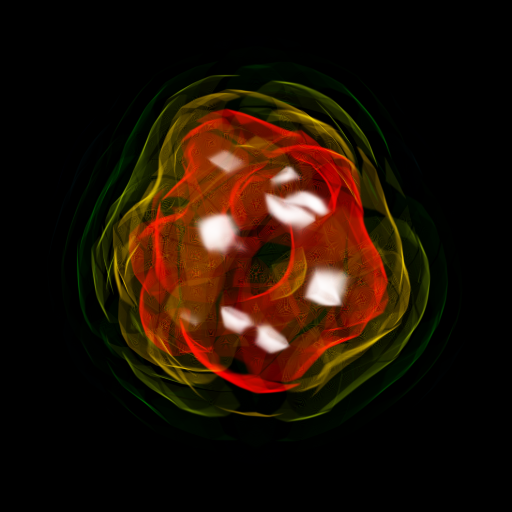

In [4]:
for batch in dl_test:
    for vector_field in batch:
        plot_field(vector_field[:, :, :, 9]).show()
    break

In [5]:
net = SirenNet(
    dim_in=4,
    dim_hidden=256,
    dim_out=1,
    num_layers=8,
    w0 = 1.0,
    w0_initial = 30.0,
    use_bias = True,
    final_activation = None
)

autoencoder = Autoencoder(
    net,
    in_channels=12,
    output_shape=[resolution, resolution, resolution, 12, 1],
    # output_shape=[resolution, resolution, resolution, 1, 1],
    latent_dim=256,
)

autoencoder.cuda()

optim = torch.optim.Adam(lr=1e-4, params=autoencoder.parameters())

/home/daenu/micromamba/envs/minf/lib/python3.11/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [6]:
for epoch in (pbar := tqdm(range(2000))):
    total_loss = 0
    for batch in dl:
        loss, out, latent = autoencoder(batch.cuda())
        optim.zero_grad()
        loss.backward()
        optim.step()

        total_loss += loss.item()
    torch.save(autoencoder.state_dict(), "model.pt")
    pbar.set_description(f"Epoch {epoch} (loss: {(total_loss / len(fd)):2f})")

Epoch 1999 (loss: 0.003549): 100%|███████████████████████████████████████████████████████████████████████| 2000/2000 [01:14<00:00, 26.87it/s]


yt : [INFO     ] 2025-02-08 10:51:04,236 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-08 10:51:04,236 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2025-02-08 10:51:04,236 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-08 10:51:04,236 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-08 10:51:04,237 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-08 10:51:04,279 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-08 10:51:04,285 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-08 10:51:04,285 Creating volume
yt : [INFO     ] 2025-02-08 10:51:04,301 Creating transfer function
yt : [INFO     ] 2025-02-08 10:51:04,301 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


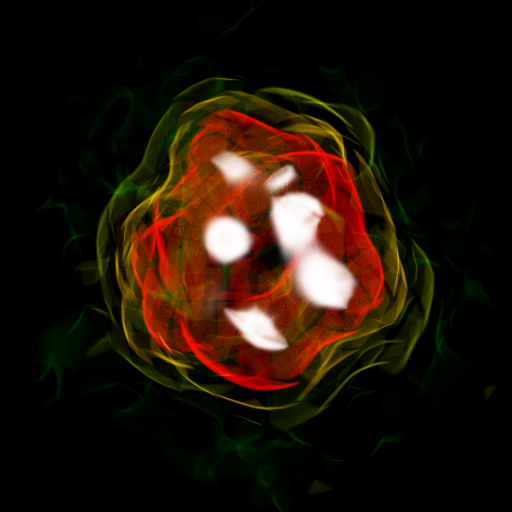

yt : [INFO     ] 2025-02-08 10:51:04,478 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-08 10:51:04,479 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2025-02-08 10:51:04,479 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-08 10:51:04,479 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-08 10:51:04,479 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-08 10:51:04,521 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-08 10:51:04,527 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-08 10:51:04,528 Creating volume
yt : [INFO     ] 2025-02-08 10:51:04,543 Creating transfer function
yt : [INFO     ] 2025-02-08 10:51:04,543 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


gt


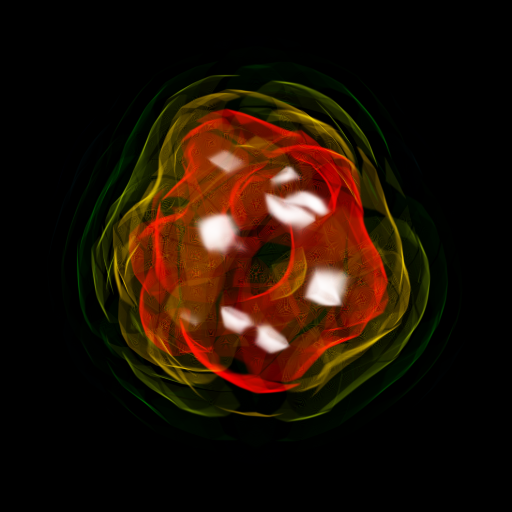

In [24]:
i = 0
for batch in dl_test:
    latent = autoencoder.encode(batch.cuda())
    reconstructed = autoencoder.predict(latent).cpu().detach()
    
    for r in reconstructed:
        plot_field(r.flatten(3)[:, :, :, 9]).show()
        print("gt")
        plot_field(fd[i][:, :, :, 9]).show()
        i += 1
    break